<a href="https://colab.research.google.com/github/1Princekumarsingh/ML_Model_From_Scartch/blob/main/linear_regression_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
df = pd.read_csv("/content/Salary_Data.csv")
X = df['YearsExperience'].values
y = df['Salary']

In [ ]:
X = np.array(X)
y = np.array(y)

<Axes: >

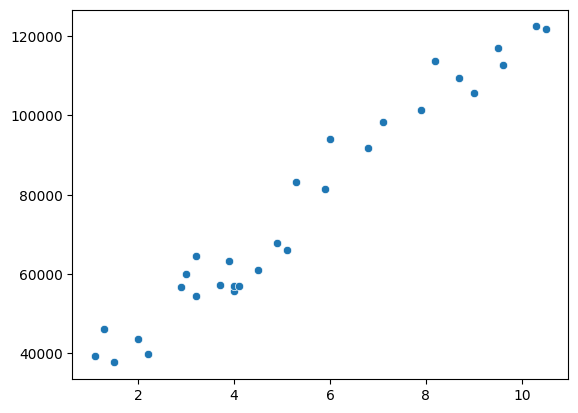

In [ ]:
sns.scatterplot(x=X,y=y)

In [ ]:
class Normalizer:
  def z_score(self, data):
    n = len(data)
    mean = sum(data)/n
    var = sum((x-mean)**2 for x in data)/n
    std = var**0.5
    return [(x-mean)/std for x in data]

In [ ]:
class LinearRegressionScratch:
  def __init__(self, lr = 0.02, max_itr = 1000, tolerance = 1e-6):
    self.lr = lr
    self.max_itr = max_itr
    self.tolerance = tolerance
    self.m = 0
    self.b = 0

  def fit(self, X, y):

    if len(X) != len(y):
      raise ValueError("X and y must have the same length.")

    n = len(X)
    m = self.m
    b = self.b
    prev_error = float('inf')

    for i in range(self.max_itr):

      y_pred = np.array([m*xi + b for xi in X])

      dm = (-2/n)*sum((y[i]-y_pred[i])*X[i] for i in range(n))
      db = (-2/n)*sum(y[i]-y_pred[i] for i in range(n))

      m -= self.lr*dm
      b -= self.lr*db

      error = sum((y[i] - y_pred[i])**2 for i in range(n))/n

      if abs(prev_error - error) < self.tolerance:
        print(f"Stopped early at iteration {i+1}")
        break

      prev_error = error

    self.m = m
    self.b = b

  def predict(self, X):
    return np.array([self.m*xi + self.b for xi in X])

In [ ]:
scalar = Normalizer()
model = LinearRegressionScratch()

In [ ]:
X_trained_scale = scalar.z_score(X)
model.fit(X_trained_scale, y)
prediction = model.predict(X_trained_scale)

Stopped early at iteration 417


In [ ]:
print("m:", model.m)
print("b:", model.b)

print("Predictions:", prediction)

m: 26367.181376533885
b: 76002.99692436415
Predictions: [ 36187.15728787  38077.14967568  39967.14206349  44692.12303301
  46582.11542082  53197.08877815  54142.08497205  56032.07735986
  56032.07735986  60757.05832938  62647.05071719  63592.04691109
  63592.04691109  64537.04310499  68317.02788061  72097.01265623
  73987.00504404  75876.99743184  81546.97459527  82491.97078917
  90051.9403404   92886.92892212 100446.89847335 103281.88705506
 108006.86802458 110841.85660629 115566.83757581 116511.83376972
 123126.80712705 125016.79951486]


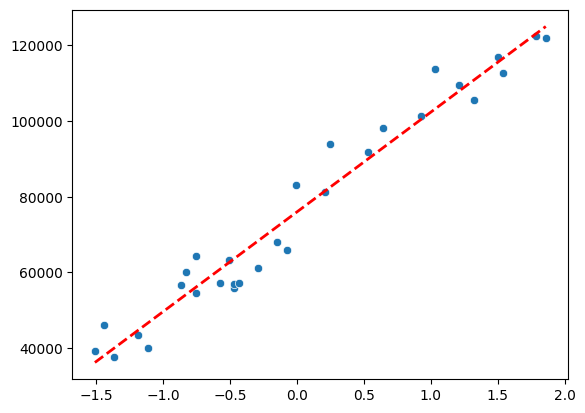

In [ ]:
from matplotlib.lines import lineStyles
sns.scatterplot(x=X_trained_scale,y=y)
plt.plot(X_trained_scale, prediction, color="red", linewidth=2, linestyle="--", label="predicted")


In [ ]:
print(f"r2 score: {r2_score(y, prediction)}")
print(f"mean square error: {mean_squared_error(y, prediction)}")

r2 score: 0.9569566641434939
mean square error: 31270951.722291563
